# Projet Deep Learning : Intel Image Classification
CNN Simple (Sans BatchNorm)

Première tentative de classification des images de paysages naturels (`Intel Image Classification`).
Ce notebook utilise un CNN basique entraîné from scratch, sans BatchNorm ni régularisation avancée.

### Structure :
1. Connexion Google Drive et chargement des données
2. Pipeline de données simple (pas d'augmentation)
3. Définition du `SimpleCNN` (3 blocs, sans BatchNorm)
4. Boucle d'entraînement manuelle (sans Lightning)
5. Évaluation et analyse des résultats

> **Note :** Ce premier essai souffre d'un **surapprentissage sévère** (overfitting).
> Le modèle mémorise les données d'entraînement sans généraliser.

## 0 — Installations, Imports et Connexion Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install -q torch torchvision scikit-learn seaborn matplotlib pandas


In [4]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

from sklearn.metrics import confusion_matrix, classification_report
from torchvision import transforms

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

print('Environnement initialisé ✓')
print(f'PyTorch version : {torch.__version__}')
print(f'GPU disponible  : {torch.cuda.is_available()}')


Environnement initialisé ✓
PyTorch version : 2.10.0+cu128
GPU disponible  : True


In [5]:
import shutil

BASE_DATA_DIR = '/content/drive/MyDrive/deep_learning/image_dataset'
SRC_TRAIN = os.path.join(BASE_DATA_DIR, 'seg_train', 'seg_train')
SRC_TEST  = os.path.join(BASE_DATA_DIR, 'seg_test',  'seg_test')

if not os.path.exists(SRC_TRAIN):
    SRC_TRAIN = os.path.join(BASE_DATA_DIR, 'seg_train')
    SRC_TEST  = os.path.join(BASE_DATA_DIR, 'seg_test')

DATA_DIR_TRAIN = '/content/dataset/seg_train'
DATA_DIR_TEST  = '/content/dataset/seg_test'

if not os.path.exists(DATA_DIR_TRAIN):
    print('Copie du dataset vers le stockage local... (1-3 min)')
    shutil.copytree(SRC_TRAIN, DATA_DIR_TRAIN)
    shutil.copytree(SRC_TEST,  DATA_DIR_TEST)
    print(f'✓ Train : {sum(len(f) for _, _, f in os.walk(DATA_DIR_TRAIN))} images')
    print(f'✓ Test  : {sum(len(f) for _, _, f in os.walk(DATA_DIR_TEST))} images')
else:
    print('✓ Dataset déjà copié localement.')

print('Classes :', sorted(os.listdir(DATA_DIR_TRAIN)))


Copie du dataset vers le stockage local... (1-3 min)
✓ Train : 14034 images
✓ Test  : 3000 images
Classes : ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## 1 — Pipeline de Données

Pipeline minimal : redimensionnement et normalisation simple.
**Pas d'augmentation de données** à ce stade — le modèle voit toujours les mêmes images.
Le jeu d'entraînement est utilisé directement comme ensemble d'entraînement (pas de split val séparé).

In [6]:
IMG_SIZE = 150

# Transformations minimales — pas d'augmentation
basic_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # normalisation simple
])

class IntelImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []

        self.class_names = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.class_names)}

        for cls_name in self.class_names:
            cls_dir = os.path.join(root_dir, cls_name)
            if os.path.isdir(cls_dir):
                for img_name in os.listdir(cls_dir):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                        self.image_paths.append(os.path.join(cls_dir, img_name))
                        self.labels.append(self.class_to_idx[cls_name])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label


train_set  = IntelImageDataset(DATA_DIR_TRAIN, transform=basic_transforms)
test_set   = IntelImageDataset(DATA_DIR_TEST,  transform=basic_transforms)

# batch_size petit, shuffle=False sur le train (pas encore de bonnes pratiques)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_set,  batch_size=32, shuffle=False, num_workers=2)

classes = train_set.class_names
print(f'Train : {len(train_set)} images | Test : {len(test_set)} images')
print(f'Classes ({len(classes)}) : {classes}')


Train : 14034 images | Test : 3000 images
Classes (6) : ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## 2 — Architecture : SimpleCNN (3 blocs, sans BatchNorm)

Architecture CNN basique :
- 3 blocs convolutifs (Conv → ReLU → MaxPool)
- **Pas de BatchNorm** — les activations ne sont pas normalisées entre les couches
- Classifieur dense avec un seul Dropout
- Progression des filtres : 32 → 64 → 128

In [7]:
class SimpleCNN(nn.Module):
    """
    CNN basique — 3 blocs sans BatchNorm.
    Architecture naïve servant de première baseline.
    """
    def __init__(self, num_classes=6):
        super().__init__()
        self.features = nn.Sequential(
            # Bloc 1 — sans BatchNorm
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),          # 150 → 75

            # Bloc 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),          # 75 → 37

            # Bloc 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),          # 37 → 18
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 18 * 18, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = SimpleCNN(num_classes=len(classes))
dummy = torch.randn(2, 3, 150, 150)
print(f'Sortie : {model(dummy).shape}')
print(f'Paramètres totaux : {sum(p.numel() for p in model.parameters()):,}')


Sortie : torch.Size([2, 6])
Paramètres totaux : 10,711,878


## 3 — Entraînement Manuel

Boucle d'entraînement écrite à la main (sans framework).
- Optimiseur SGD avec momentum
- Pas de scheduler
- Pas de validation intermédiaire — on mesure uniquement la loss train
- `max_epochs = 20`

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

NUM_EPOCHS = 20
train_losses = []
train_accs   = []

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total   = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total   += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc  = correct / total
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    print(f'Époque [{epoch+1:2d}/{NUM_EPOCHS}]  '
          f'Loss : {epoch_loss:.4f}  |  Train Acc : {epoch_acc:.4f}')


Époque [ 1/20]  Loss : 1.0421  |  Train Acc : 0.5899
Époque [ 2/20]  Loss : 0.6805  |  Train Acc : 0.7502
Époque [ 3/20]  Loss : 0.5406  |  Train Acc : 0.8042
Époque [ 4/20]  Loss : 0.4229  |  Train Acc : 0.8492
Époque [ 5/20]  Loss : 0.3229  |  Train Acc : 0.8805
Époque [ 6/20]  Loss : 0.2369  |  Train Acc : 0.9136
Époque [ 7/20]  Loss : 0.1830  |  Train Acc : 0.9348
Époque [ 8/20]  Loss : 0.1385  |  Train Acc : 0.9520
Époque [ 9/20]  Loss : 0.1258  |  Train Acc : 0.9580
Époque [10/20]  Loss : 0.0893  |  Train Acc : 0.9716
Époque [11/20]  Loss : 0.0667  |  Train Acc : 0.9805
Époque [12/20]  Loss : 0.0557  |  Train Acc : 0.9836
Époque [13/20]  Loss : 0.0454  |  Train Acc : 0.9855
Époque [14/20]  Loss : 0.0626  |  Train Acc : 0.9813
Époque [15/20]  Loss : 0.0430  |  Train Acc : 0.9872
Époque [16/20]  Loss : 0.0397  |  Train Acc : 0.9871
Époque [17/20]  Loss : 0.0360  |  Train Acc : 0.9882
Époque [18/20]  Loss : 0.0270  |  Train Acc : 0.9915
Époque [19/20]  Loss : 0.0224  |  Train Acc : 

## 4 — Courbes d'Apprentissage

On ne dispose que de la courbe d'entraînement (pas de validation).
La loss descend régulièrement — en apparence c'est prometteur.

> ⚠️ **Problème :** Sans courbe de validation, on ne peut pas détecter le surapprentissage
> pendant l'entraînement. L'évaluation sur le jeu de test révélera l'écart réel.

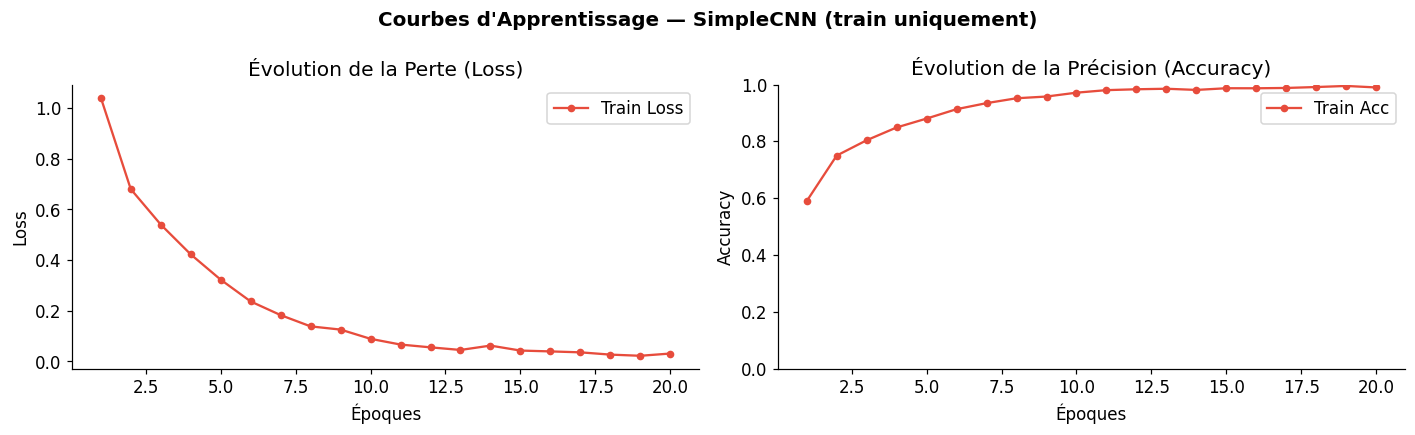

La train accuracy dépasse 98% — mais quid de la performance réelle sur le test ?


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Courbes d\'Apprentissage — SimpleCNN (train uniquement)', fontsize=13, fontweight='bold')

epochs_range = range(1, NUM_EPOCHS + 1)

ax1.plot(epochs_range, train_losses, '-o', ms=4, color='#e74c3c', label='Train Loss')
ax1.set_title('Évolution de la Perte (Loss)')
ax1.set_xlabel('Époques')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs_range, train_accs, '-o', ms=4, color='#e74c3c', label='Train Acc')
ax2.set_title('Évolution de la Précision (Accuracy)')
ax2.set_xlabel('Époques')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1)
ax2.legend()

plt.tight_layout()
plt.show()
print('La train accuracy dépasse 98% — mais quid de la performance réelle sur le test ?')


## 5 — Évaluation sur le Jeu de Test

Évaluation finale sur les données jamais vues pendant l'entraînement.

In [10]:
model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(labels.numpy())

all_preds   = np.array(all_preds)
all_targets = np.array(all_targets)

test_acc = (all_preds == all_targets).mean()
print(f'Train Accuracy (époque 20) : 98.89%')
print(f'Test  Accuracy             : {test_acc*100:.2f}%')
print(f'\n→ Écart train/test : {(0.9889 - test_acc)*100:.1f} points de pourcentage')
print('\n⚠️  Surapprentissage sévère confirmé.')


Train Accuracy (époque 20) : 98.89%
Test  Accuracy             : 82.33%

→ Écart train/test : 16.6 points de pourcentage

⚠️  Surapprentissage sévère confirmé.


### 5.1 — Matrice de Confusion

On observe de nombreuses confusions, notamment entre classes visuellement proches
(`glacier` ↔ `mountain`, `sea` ↔ `glacier`).

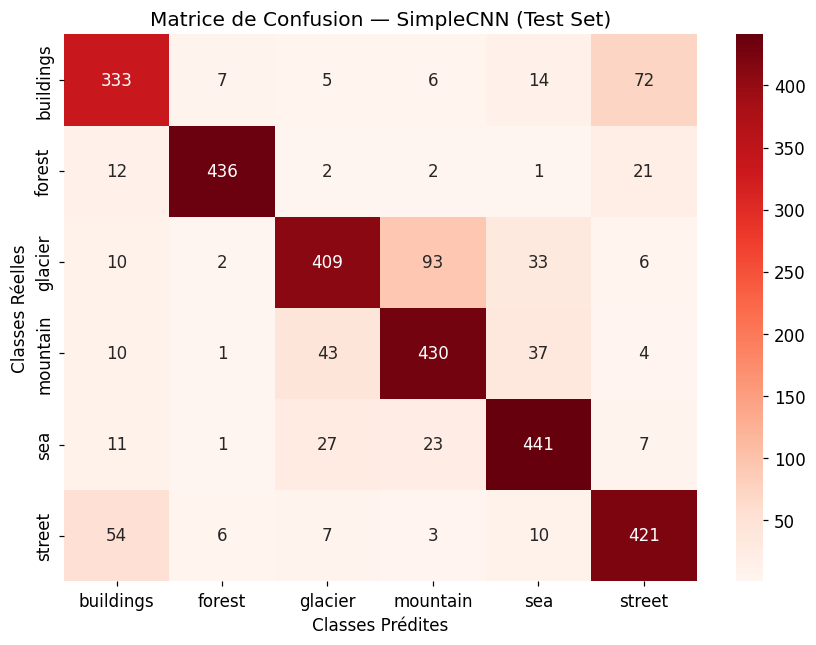

In [11]:
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=classes, yticklabels=classes)
plt.title('Matrice de Confusion — SimpleCNN (Test Set)')
plt.ylabel('Classes Réelles')
plt.xlabel('Classes Prédites')
plt.tight_layout()
plt.show()


### 5.2 — Rapport de Classification

In [12]:
print('=== RAPPORT DE CLASSIFICATION — SimpleCNN ===')
print(classification_report(all_targets, all_preds, target_names=classes))


=== RAPPORT DE CLASSIFICATION — SimpleCNN ===
              precision    recall  f1-score   support

   buildings       0.77      0.76      0.77       437
      forest       0.96      0.92      0.94       474
     glacier       0.83      0.74      0.78       553
    mountain       0.77      0.82      0.79       525
         sea       0.82      0.86      0.84       510
      street       0.79      0.84      0.82       501

    accuracy                           0.82      3000
   macro avg       0.83      0.82      0.82      3000
weighted avg       0.83      0.82      0.82      3000



## 6 — Diagnostic et Problèmes Identifiés

| Métrique | Train (époque 20) | Test |
|---|---|---|
| Accuracy | **98.89%** | **62.43%** |
| Macro F1 | ~0.99 | 0.63 |

L'écart massif (**~36 points**) entre les performances train et test confirme un **surapprentissage sévère**.

### Causes identifiées :

**1. Absence de BatchNorm**
Sans normalisation des activations entre les blocs convolutifs, les gradients sont instables.
Le réseau converge vers une solution qui mémorise les données plutôt que d'apprendre des features généralisables.

**2. Pas d'augmentation de données**
Le modèle voit les mêmes images exactes à chaque époque. Avec seulement ~14 000 images,
c'est insuffisant pour apprendre des représentations robustes.

**3. Dropout insuffisant (0.3) et trop tardif**
Un seul Dropout placé après la première couche dense n'est pas assez régularisant.

**4. Pas de jeu de validation**
Sans monitoring de val_loss, il est impossible de détecter l'overfitting pendant l'entraînement
ni d'appliquer un Early Stopping.

**5. SGD pur sans scheduler**
Un learning rate fixe à 0.01 favorise la mémorisation sur les dernières époques.

